/var/folders/vc/zqm44p0x6dx4m48jclbr5q280000gn/T/ipykernel_12308/418015127.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(df.values, labels=df.columns, boxprops=boxprops, medianprops=medianprops,


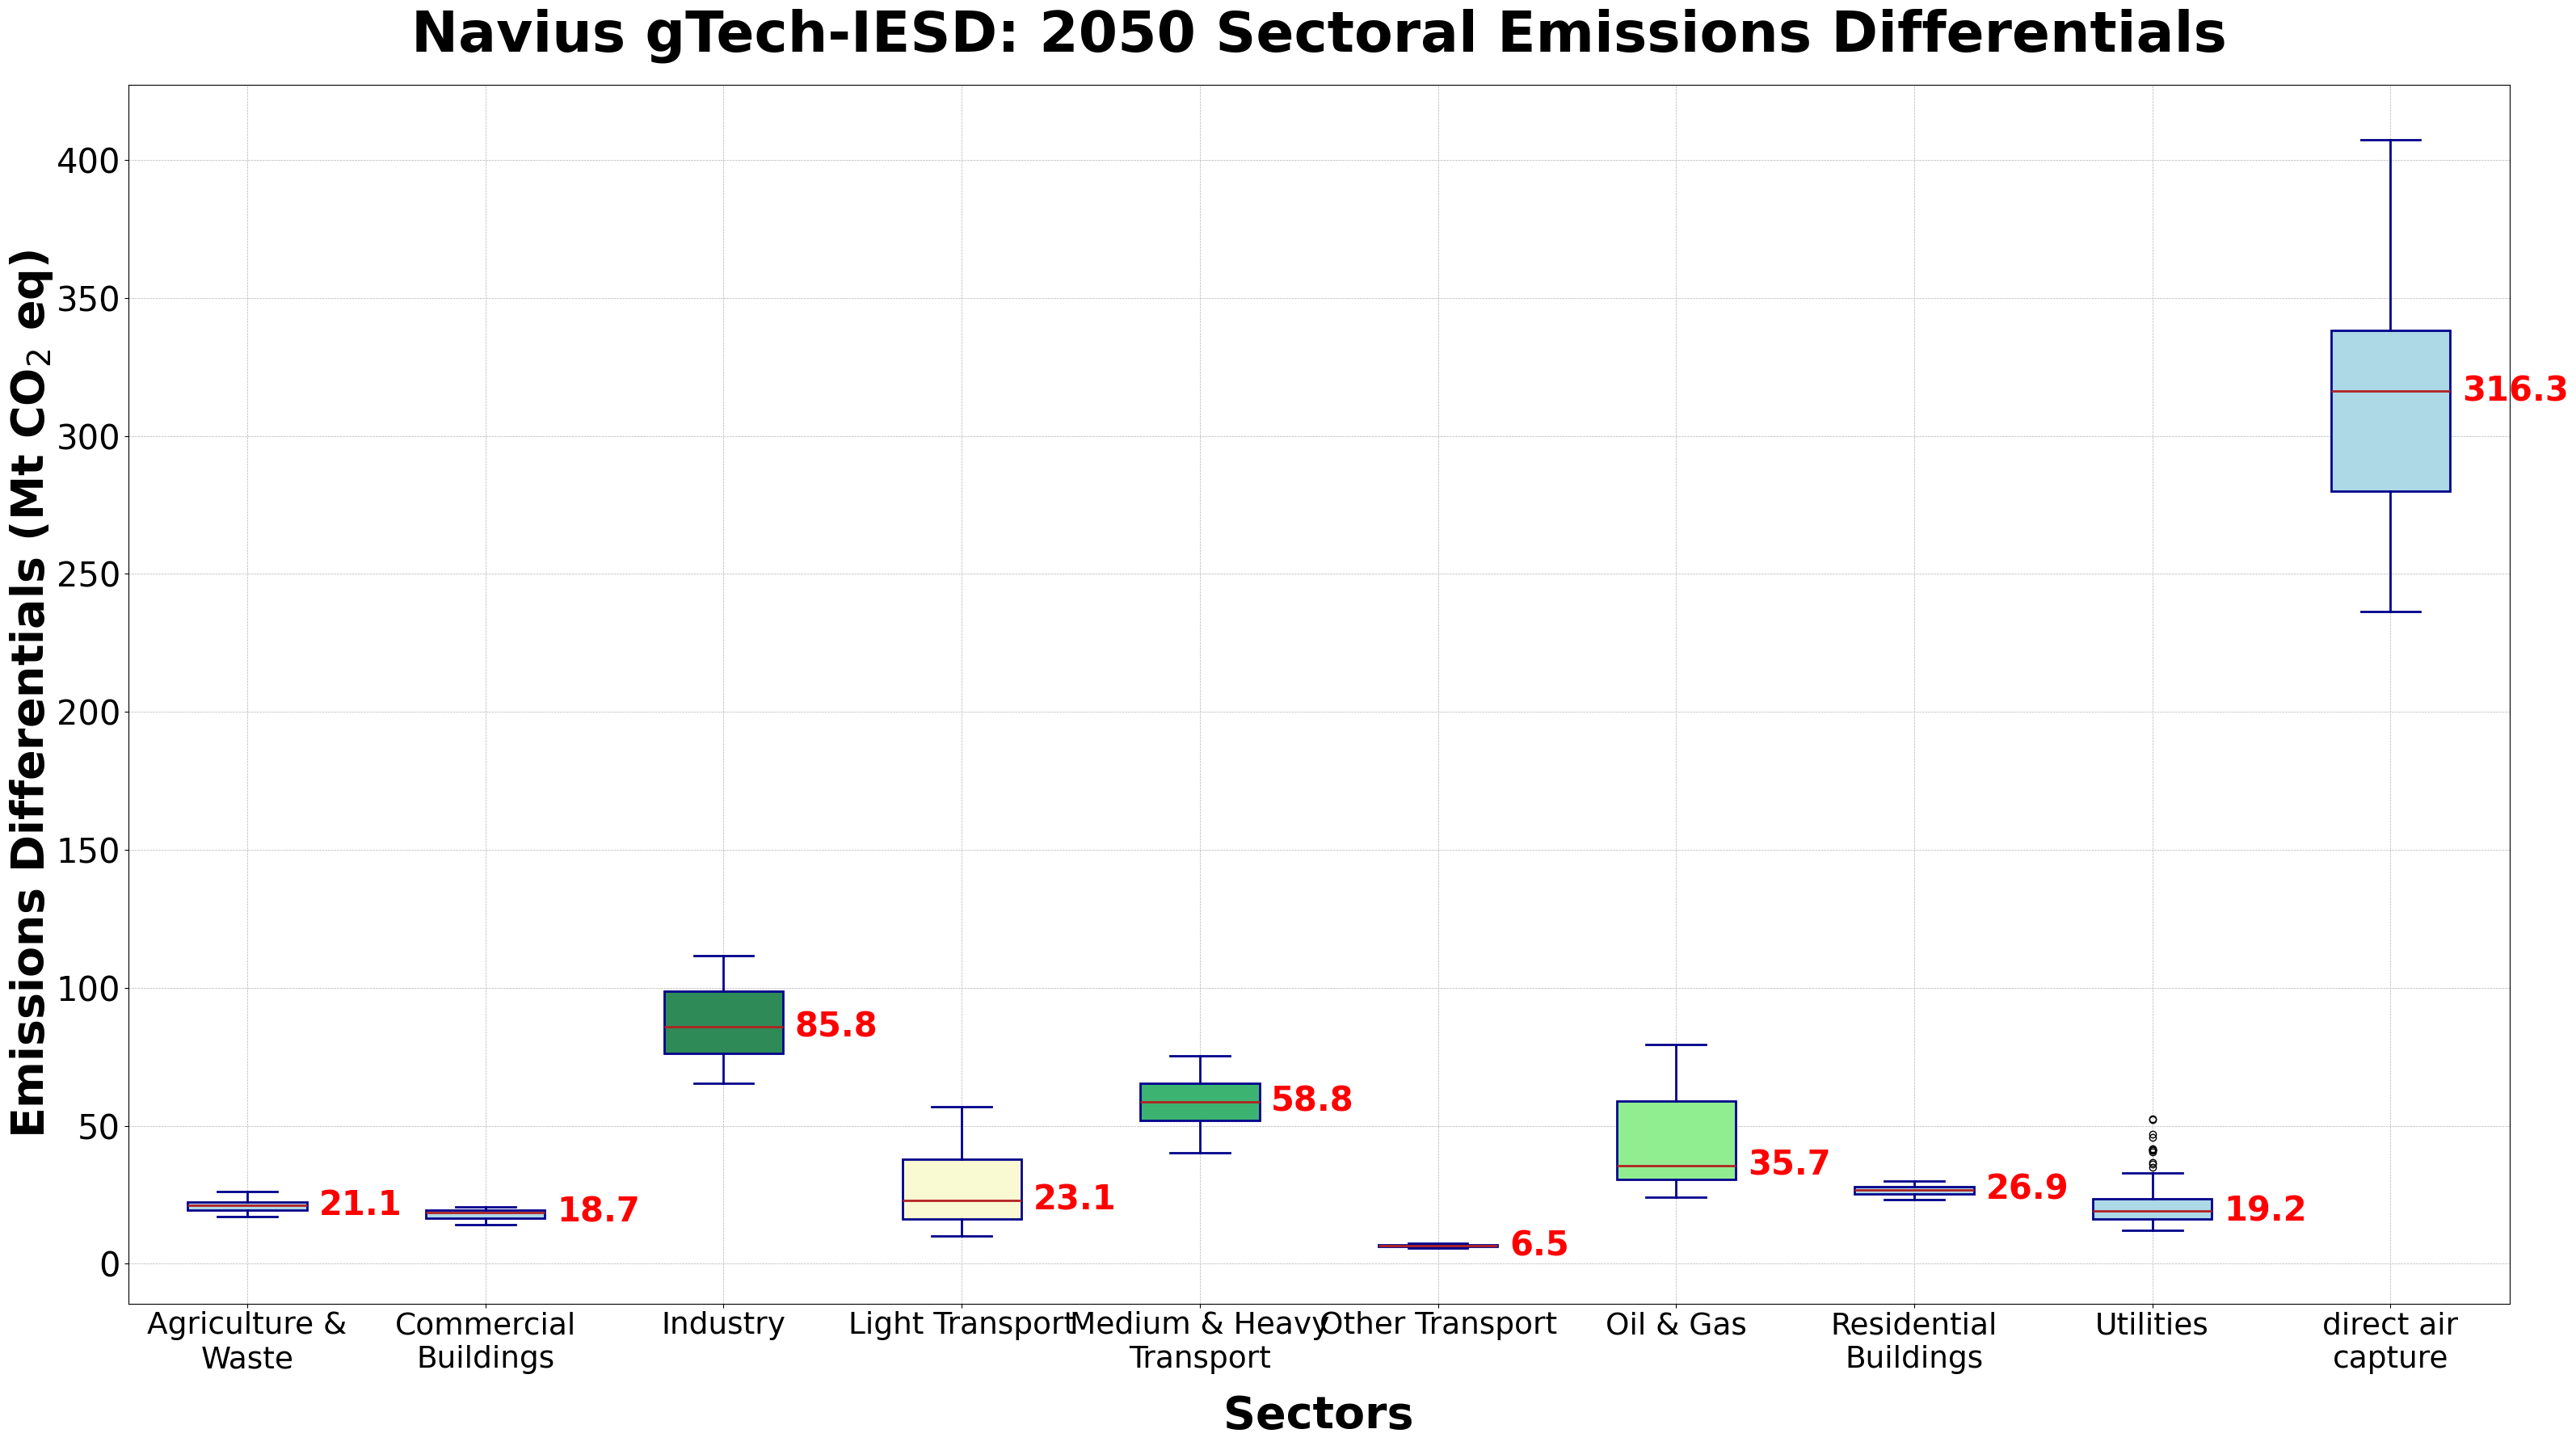

'\n# -*- coding: utf-8 -*-\n\nCreated on Mon Mar 25 14:38:32 2024\n\n@author: Feras Abdulla\n\n\nimport matplotlib.pyplot as plt\nimport pandas as pd\nimport textwrap\n\n# Read data from Excel file\ndf = pd.read_excel("2050 Emissions Deltas - Navius.xlsx")\n\n# Create boxplot\nplt.figure(figsize=(48, 24))  # Adjust figure size as needed\nplt.boxplot(df.values, labels=df.columns)\n\n# Function to wrap text for tick labels\ndef wrap_labels(labels, width):\n    return [\'\n\'.join(textwrap.wrap(label, width)) for label in labels]\n\n# Wrap x-axis labels\nwrapped_labels = wrap_labels(df.columns, 10)  # Adjust width as needed\n\n\n# Add labels for max, min\nfor i, col in enumerate(df.columns):\n    plt.text(i + 1, df[col].max(), f\'{df[col].max():.1f}\', ha=\'center\', va=\'bottom\', color=\'red\', fontsize=12)\n    plt.text(i + 1, df[col].min(), f\'{df[col].min():.1f}\', ha=\'center\', va=\'top\', color=\'red\', fontsize=12)\n\n# Add labels for median to the right of each box\nfor i, col i

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import textwrap

# Read data from Excel file
df = pd.read_excel("2050 Emissions Deltas - Navius.xlsx")

# Create a figure and axis
fig, ax = plt.subplots(figsize=(32, 18))  # Increase figure size to accommodate the changes

# Customize boxplot colors
boxprops = dict(linewidth=2, color='darkblue')
medianprops = dict(linewidth=2, color='firebrick')
whiskerprops = dict(linewidth=2, color='darkblue')
capprops = dict(linewidth=2, color='darkblue')

# Create boxplot with customized properties
bp = ax.boxplot(df.values, labels=df.columns, boxprops=boxprops, medianprops=medianprops,
                whiskerprops=whiskerprops, capprops=capprops, patch_artist=True)

# Set specific colors for each box
colors = ['lightblue'] * len(df.columns)
colors[2] = 'seagreen'
colors[4] = 'mediumseagreen'
colors[6] = 'lightgreen'
colors[3] = 'lightgoldenrodyellow'

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

# Function to wrap text for tick labels
def wrap_labels(labels, width):
    return ['\n'.join(textwrap.wrap(label, width)) for label in labels]

# Wrap x-axis labels with a wider width
wrapped_labels = wrap_labels(df.columns, 15)  # Increase width to avoid awkward breaks

'''
# Add labels for max, min with adjusted offset for specific boxes
for i, col in enumerate(df.columns):
    if i in [0, 1, 5, 7]:  # Adjusted boxes (1, 2, 6, 8 in zero-indexed)
        plt.text(i + 1, df[col].max() + 0.1 * (df[col].max() - df[col].min()), f'{df[col].max():.1f}', ha='center', va='bottom', color='red', fontsize=18, fontweight='bold')
        plt.text(i + 1, df[col].min() - 0.1 * (df[col].max() - df[col].min()), f'{df[col].min():.1f}', ha='center', va='top', color='red', fontsize=18, fontweight='bold')
    else:  # Default offset for other boxes
        plt.text(i + 1, df[col].max() + 0.05 * (df[col].max() - df[col].min()), f'{df[col].max():.1f}', ha='center', va='bottom', color='red', fontsize=18, fontweight='bold')
        plt.text(i + 1, df[col].min() - 0.05 * (df[col].max() - df[col].min()), f'{df[col].min():.1f}', ha='center', va='top', color='red', fontsize=18, fontweight='bold')
'''
# Add labels for median with adjusted horizontal offset
for i, col in enumerate(df.columns):
    plt.text(i + 1.3, df[col].median(), f'{df[col].median():.1f}', ha='left', va='center', color='red', fontsize=30, fontweight='bold')  # Reduced horizontal offset

# Add labels and title with improved font and additional padding
plt.xlabel('Sectors', fontsize=40, fontweight='bold', labelpad=18)  # Increase label padding
plt.ylabel('Emissions Differentials (Mt CO$_2$ eq)', fontsize=40, fontweight='bold', labelpad=1)
plt.title('Navius gTech-IESD: 2050 Sectoral Emissions Differentials', fontsize=50, fontweight='bold', pad=30)  # Increase title padding

# Apply wrapped labels and rotate them for better readability
plt.xticks(ticks=range(1, len(df.columns) + 1), labels=wrapped_labels, rotation=0, fontsize=27)  # Set rotation to 0

# Increase the y-axis tick label size
plt.yticks(fontsize=30)  # Increase font size a little bit

# Add grid lines
ax.grid(True, linestyle='--', linewidth=0.5)

# Remove the legend
# plt.legend(['Max', 'Min', 'Median'], loc='upper right', fontsize=14)

# Adjust subplot parameters for more space
plt.subplots_adjust(left=0.05, right=0.95, top=0.9, bottom=0.2)


plt.tight_layout()

# Show plot
plt.show()